# SNN Hackathon 2026

## Day 1: Data loading, merging and filtering


### 0. Imports & Setup


In [ ]:
import mne
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os

mne.set_log_level('WARNING')  # reduce verbose output

print('MNE version:', mne.__version__)

MNE version: 1.11.0


In [123]:
# ── Paths & participant ID ────────────────────────────────────────────────────
# Adjust this path to wherever your data is stored
DATA_DIR = '../data/hackathon_data'
sub_id   = 'sub-1'

raw_path = f'{DATA_DIR}/{sub_id}/eeg/{sub_id}_task-gonogo.vhdr'
print(f'Working on: {sub_id}')
print(f'File:       {raw_path}')

Working on: sub-1
File:       ../data/hackathon_data/sub-1/eeg/sub-1_task-gonogo.vhdr



### 1. Load the raw data for participant 1

Let's try to load the raw data for participant 1 now. We will use the mne.io.read_raw_brainvision() function to read the .vhdr file. Afterwards we will have our first look at the raw data and its properties.


── Raw info ──────────────────
<Info | 7 non-empty values
 bads: []
 ch_names: Fp1, Fz, F3, F7, F9, FC5, FC1, C3, T7, CP5, CP1, Pz, P3, P7, P9, ...
 chs: 63 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 140.0 Hz
 meas_date: 2026-03-27 15:03:21 UTC
 nchan: 63
 projs: []
 sfreq: 500.0 Hz
>
Duration: 1392.0 s
Channels: 63


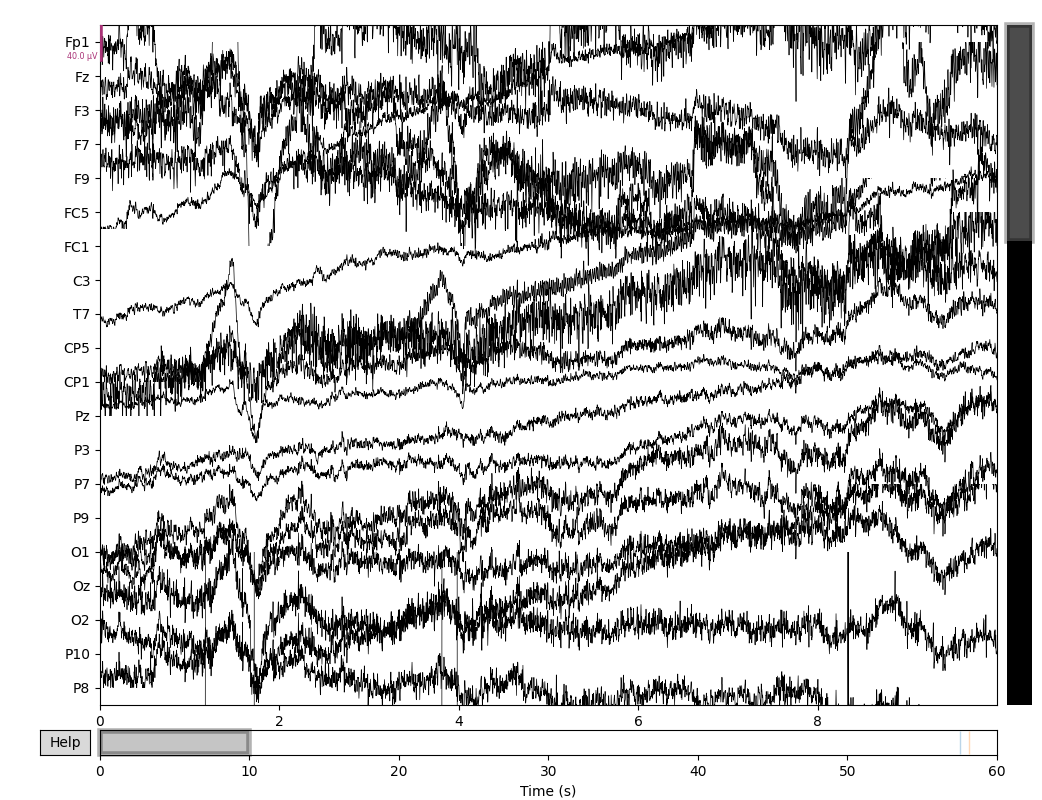

In [124]:
# load the raw data for participant 1
raw = mne.io.read_raw_brainvision(raw_path, preload=True)
# NOTE: some operations require preloading of the data (like filtering or merging), without this parameter, data is just memory-mapped and loaded to RAM as needed.

# show some basic information about the raw data
print('\n── Raw info ──────────────────')
print(raw.info)

# show the duration of the recording and number of channels
print(f'Duration: {raw.times[-1]:.1f} s')
print(f'Channels: {len(raw.ch_names)}')

# plot the raw data to visually inspect it

%matplotlib widget
mne.viz.set_browser_backend('matplotlib')

#alternative to widget is qt, if you want it in a popup window
#requires to have ipympl and ipywidgets installed in your environment!
#if you do not want interactive plots, replace widget with inline
#the interactive plot requires to have ipympl and ipywidgets installed in your environment!
raw_short = raw.copy().crop(tmax=60)
raw_short.plot(n_channels=20, duration=10, title='Raw EEG Data - Participant 1',)

del raw_short


### 2. Merging two datasets for the same participant
We have a problem in our datasets: For one of the participants, the recording stopped abruptly. Since we still wanted to finish the experiment, we restarted the recording and continued with the same participant. This means that we have two separate raw files for this participant, which we need to merge together before we can continue with preprocessing. Let's see how we can do this with MNE.

In [ ]:
# set the data paths for participant X
sub_id_2 = 'sub-5'
path_1 = f'{DATA_DIR}/{sub_id_2}/eeg/{sub_id_2}_task-gonogo_part1.fif'
path_2 = f'{DATA_DIR}/{sub_id_2}/eeg/{sub_id_2}_task-gonogo_part2.fif'

# load the two raw files for participant X
raw1 = mne.io.read_raw_fif(path_1, preload=True)
raw2 = mne.io.read_raw_fif(path_2, preload=True)

# merge the two raw files together
raw_merged = mne.concatenate_raws([raw1.copy(), raw2.copy()])

# To check whether we merged correctly, compare the length of the raw files
print(f'Length of raw1: {raw1.duration} s')
print(f'Length of raw2: {raw2.duration} s')
print(f'Length of sum of both individual raw files: {raw1.duration + raw2.duration} s')
print(f'Length of merged raw: {raw_merged.duration} s')

# look at the annotations to see a 'BAD boundary' listed.
# this is the marker that signifies where the data has been merged
print(raw.annotations)
print(raw_merged.annotations) #[143]


# save the merged raw file for participant 5
raw_merged.save(f'{DATA_DIR}/{sub_id_2}/eeg/{sub_id_2}_task-gonogo_merged_raw.fif', overwrite=True)


C:\Users\asuka\AppData\Local\Temp\ipykernel_130076\3022355141.py:7: RuntimeWarning: This filename (../data/hackathon_data/sub-5/eeg/sub-5_task-gonogo_part1.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw1 = mne.io.read_raw_fif(path_1, preload=True)
C:\Users\asuka\AppData\Local\Temp\ipykernel_130076\3022355141.py:8: RuntimeWarning: This filename (../data/hackathon_data/sub-5/eeg/sub-5_task-gonogo_part2.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw2 = mne.io.read_raw_fif(path_2, preload=True)


Length of raw1: 300.002 s
Length of raw2: 1091.02 s
Length of sum of both individual raw files: 1391.022 s
Length of merged raw: 1391.022 s
<Annotations | 369 segments: Stimulus/S 1 (54), Stimulus/S 2 (52), ...>
<Annotations | 738 segments: BAD boundary (1), EDGE boundary (1), ...>


[WindowsPath('c:/Users/asuka/Documents/SNN/EEG_Hackathon_Workshop/Hackathon_pipeline/Hackathon_Scripts/../data/hackathon_data/sub-5/eeg/sub-5_task-gonogo_merged_raw.fif')]


## 3. Filtering the data
Now let's get back to participant 1 which we already loaded into memory. If it is not loaded anymore, just repeat step 1 to load it again. In order to prepare the data for further analysis, we will now apply a band-pass filter to the raw data. This will help us to remove slow drifts and high-frequency noise from the data, which can interfere with our analysis. We will use a band-pass filter with a low cutoff frequency of 1 Hz and a high cutoff frequency of 40 Hz, which is a common choice for EEG data.



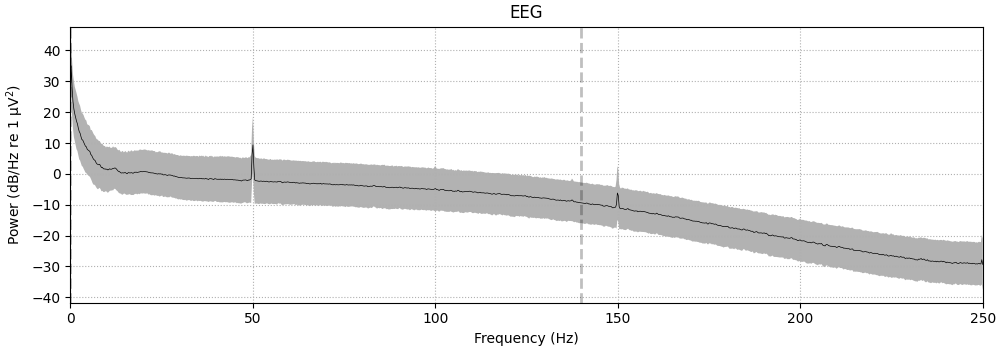

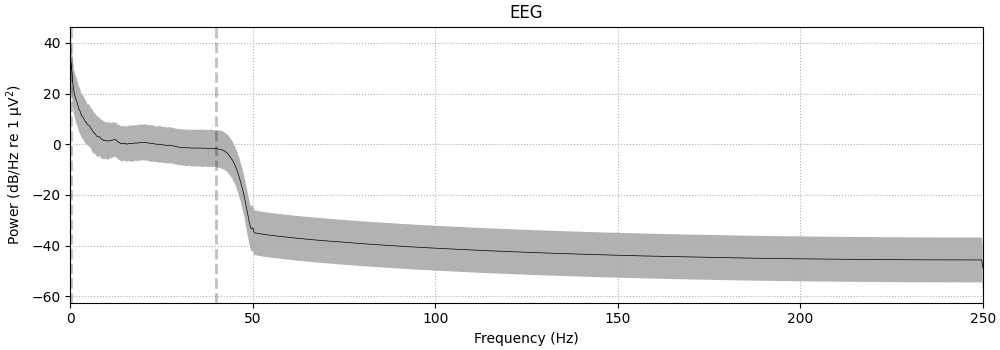

In [130]:
plt.close('all')
# Before we filter we first look at what we are actually filtering out by plotting the power spectral density (PSD) of the raw data
spectrum = raw.compute_psd()
spectrum.plot(average=True, picks='data', exclude='bads', amplitude=False, show = False);


# Now we apply the band-pass filter to the raw data
raw.filter(l_freq=0.2, h_freq= 40)

# After filtering, we can again look at the power spectral density to see how the filter has affected the data
spectrum_filtered = raw.compute_psd()
spectrum_filtered.plot(average=True, picks='data', exclude='bads', amplitude=False, show = False);
 


## 4. Resampling the Data
After filtering, we will resample the data to a lower sampling rate. This can help to reduce the computational load for further analysis steps, while still retaining the relevant information in the data. We will resample the data to 256 Hz.
Importantly we need to include our events here, since the resampling can create small shifts in the data, which can lead to misalignment between the events and the data. By including the events in the resampling process, we can ensure that they remain properly aligned with the data after resampling.


New sampling frequency: 256.0 Hz


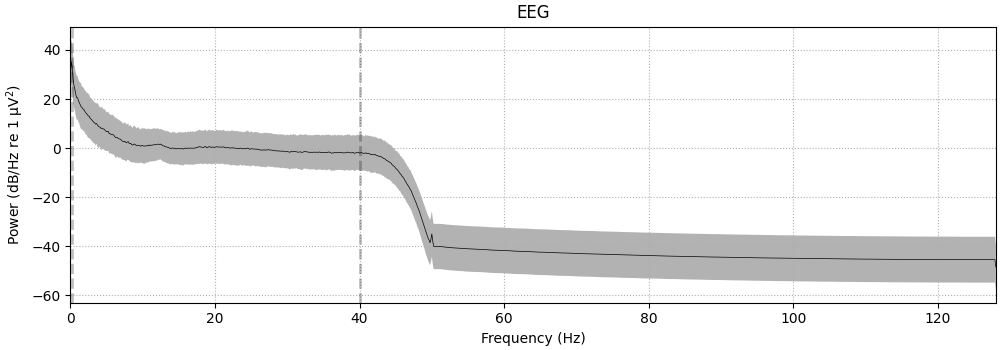

In [131]:
plt.close('all')

# Extract events (returns a tuple: events array + event_id mapping)
events, event_id = mne.events_from_annotations(raw)

# Resample raw dataset (annotations in raw are time-based and survive resampling automatically;
# therefore pass the sample-based events array so their indices get adjusted to the new sampling rate)
events = raw.resample(sfreq=256, events=events)

# Test whether the resampling worked by looking at the new sampling frequency
print(f'New sampling frequency: {raw.info["sfreq"]} Hz')

# May also look at the power spectral density again to see how the resampling has affected the data
# the maximum frequency that can be represented has changed! (Look up the Nyquist-Shannon Theorem :])
spectrum_resampled = raw.compute_psd()
spectrum_resampled.plot(average=True, picks='data', exclude='bads', amplitude=False, show = False);

## 5. Save the preprocessed raw data
Finally, we will save the preprocessed raw data to a new file, which we can then use for further analysis steps in the next days of the hackathon.

In [132]:
# save the preprocessed raw data to a new file
preprocessing_path = f'{DATA_DIR}/derivatives/{sub_id}/eeg'
os.makedirs(preprocessing_path, exist_ok=True)
file_path = f'{preprocessing_path}/{sub_id}_filtered_raw.fif'
raw.save(file_path, overwrite=True)
print(f'Preprocessed raw data saved to: {file_path}')

###NOTE: Files must end with very specific endings as listed in MNE documentation, for instance, raw files should always end with '_raw.fif'.

Preprocessed raw data saved to: ../data/hackathon_data/derivatives/sub-1/eeg/sub-1_filtered_raw.fif



## 6. Final Task: All Participants
Now that we have successfully preprocessed the data for participant 1, we can wrap everything in a for-loop to preprocess the data for all participants in our dataset. This will allow us to efficiently work on all datasets without having to repeat the same steps manually for each one. Data for each participant will be loaded, filtered, resampled and saved in a new file with the same name but with the suffix '_preprocessed' to indicate that it has been preprocessed.

## Bonus Task
Add some of the plotting functionalities that we used before for the for-loop, so that we can visually inspect the preprocessing steps for each participant. For instance, you could plot the raw data before and after filtering, or the power spectral density before and after resampling, to see how the preprocessing steps have affected the data for each participant.

In [133]:
# List of participant IDs to preprocess
participants = ['sub-1', 'sub-2', 'sub-3', 'sub-4']  # add all participant IDs here

for sub_id in participants:
    print(f'\n── Processing {sub_id} ──────────────────────────────')

    # Load the raw data for this participant
    raw_path = f'{DATA_DIR}/{sub_id}/eeg/{sub_id}_task-gonogo.vhdr'
    raw = mne.io.read_raw_brainvision(raw_path, preload=True)

    # Filter the data
    raw.filter(l_freq=0.2, h_freq=40)

    # Extract events and resample (unpack the tuple from events_from_annotations)
    events, event_id = mne.events_from_annotations(raw)
    events = raw.resample(sfreq=256, events=events)

    # Save the preprocessed raw data to a new file
    preprocessing_path = f'{DATA_DIR}/derivatives/{sub_id}/eeg'
    os.makedirs(preprocessing_path, exist_ok=True)
    file_path = f'{preprocessing_path}/{sub_id}_filtered_raw.fif'
    raw.save(file_path, overwrite=True)
    print(f'Preprocessed raw data saved to: {file_path}')


── Processing sub-1 ──────────────────────────────
Preprocessed raw data saved to: ../data/hackathon_data/derivatives/sub-1/eeg/sub-1_filtered_raw.fif

── Processing sub-2 ──────────────────────────────
Preprocessed raw data saved to: ../data/hackathon_data/derivatives/sub-2/eeg/sub-2_filtered_raw.fif

── Processing sub-3 ──────────────────────────────
Preprocessed raw data saved to: ../data/hackathon_data/derivatives/sub-3/eeg/sub-3_filtered_raw.fif

── Processing sub-4 ──────────────────────────────
Preprocessed raw data saved to: ../data/hackathon_data/derivatives/sub-4/eeg/sub-4_filtered_raw.fif
